# Multiplex Classification Comparison

| | **Dataset 1 (DS1)** | **Dataset 2 (DS2)** |
|---|---|---|
| Source | `LAB_Multiplex/02_ACA_qdPCR_balanced` | `LAB_DDM_paper/12_ACA_qdPCR_multiplex_balanced` |
| Approach | Multilabel (binary per target) | Multiclass (7 consolidated classes) |

**Metrics** (all ∈ [0, 1], higher = better)

| Metric | Formula |
|---|---|
| Exact accuracy | all labels match |
| Hamming score | element-wise label accuracy (1 − hamming_loss) |
| Strict Hamming | 0 if any false positive; else label accuracy |
| Jaccard score | \|y ∩ ŷ\| / \|y ∪ ŷ\| per sample, averaged |

**Sections:** Baselines · A (All families, DS1) · B (Cross-dataset CNN+GRU) · C (CNN+GRU deep dive) · D (Per-label / Per-combination) · E (Suggestions)

In [1]:
import json, sys, math
from pathlib import Path

import joblib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT_ML  = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex')
DATA_ROOT_DDM = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper')
DS1_NAME = '02_ACA_qdPCR_balanced'
DS2_NAME = '12_ACA_qdPCR_multiplex_balanced'

TARGET_NAMES = ['KPC', 'NDM', 'VIM']          # binary vector column order
BASE_COLORS  = {'KPC': '#E64A19', 'NDM': '#1565C0', 'VIM': '#2E7D32'}
LABEL_REMAP  = {'KPC_NDM': 'NDM_KPC', 'KPC_VIM': 'VIM_KPC', 'KPC_NDM_VIM': 'NDM_VIM_KPC'}
LABEL_ORDER  = ['NDM', 'VIM', 'KPC', 'NDM_VIM', 'NDM_KPC', 'VIM_KPC', 'NDM_VIM_KPC']

# 2^3 = 8 labels for confusion matrices
CM_LABELS = LABEL_ORDER + ['empty']
CM_DISP   = [l.replace('_', '+') if l != 'empty' else '∅' for l in CM_LABELS]

# Dataset 2: sorted raw labels (alphabetical) → int 0-6 → binary [KPC, NDM, VIM]
DS2_BIN_MAP = np.array([
    [1,0,0],[0,1,0],[1,1,0],[0,0,1],[1,0,1],[0,1,1],[1,1,1]
])

FAMILY_COLORS = {
    'CNN':'#1565C0','GRU':'#2E7D32','Transformer':'#6A1B9A',
    'CNN+GRU':'#E64A19','CNN+Trans':'#00838F',
}
GRU_GROUP_COLORS = {
    'Base':'#E64A19','CRF-MRF':'#BF360C','CRF-Chain':'#F57F17',
    'CAttn':'#880E4F','CAttn-v2':'#AD1457',
}
DS_COLORS = {'DS1 (multilabel)':'#E64A19','DS2 (multiclass)':'#1565C0'}


In [2]:
d1_main  = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_10fold.joblib')[None]
d1_crf   = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_crf_10fold.joblib')[None]
d1_cattn = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_cattn_v2_10fold.joblib')[None]
d1_xattn = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_cross_attn_10fold.joblib')[None]

d2_raw = joblib.load(DATA_ROOT_DDM / DS2_NAME / 'classification_performances_10fold.joblib')
d2 = d2_raw['Ori Curves']['Native'][None]

y_trues_d1 = [np.array(yt) for yt in d1_main['y_trues_']]      # list of (N, 3) binary
y_trues_d2 = [DS2_BIN_MAP[np.array(yt)] for yt in d2['y_trues_']]  # list of (N, 3) binary

print(f'DS1: {len(y_trues_d1)} folds, N/fold ≈ {len(y_trues_d1[0])}')
print(f'DS2: {len(y_trues_d2)} folds, N/fold ≈ {len(y_trues_d2[0])}')


DS1: 5 folds, N/fold ≈ 2077
DS2: 5 folds, N/fold ≈ 2077


In [3]:
def exact_acc(y_true, y_pred):
    return float(np.mean(np.all(y_true == y_pred, axis=1)))

def hamming_sc(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def strict_hamming_sc(y_true, y_pred):
    fp = np.sum((1 - y_true) * y_pred, axis=1)
    return float(np.where(fp > 0, 0.0, np.mean(y_true == y_pred, axis=1)).mean())

def jaccard_sc(y_true, y_pred):
    inter = np.sum(y_true & y_pred, axis=1).astype(float)
    union = np.sum(y_true | y_pred, axis=1).astype(float)
    return float(np.mean(np.where(union > 0, inter / union, 1.0)))

METRICS = [
    ('exact',   'Exact Accuracy',       exact_acc),
    ('hamming', 'Hamming Score',        hamming_sc),
    ('strict',  'Strict Hamming',       strict_hamming_sc),
    ('jaccard', 'Jaccard Score',        jaccard_sc),
]

def compute_metrics(y_trues_bin, y_preds_bin):
    out = {}
    for name, _, fn in METRICS:
        vals = [fn(yt, yp) for yt, yp in zip(y_trues_bin, y_preds_bin)]
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out


In [4]:
DS1_ALL_FAMILIES = [
    ('CNN       SC0','CNN',        d1_main,'cnn_'),
    ('CNN       SC1','CNN',        d1_main,'cnn_supcon_'),
    ('GRU       SC0','GRU',        d1_main,'gru_'),
    ('GRU       SC1','GRU',        d1_main,'gru_supcon_'),
    ('Trans     SC0','Transformer',d1_main,'transformer_'),
    ('Trans     SC1','Transformer',d1_main,'transformer_supcon_'),
    ('CNN+GRU   SC0','CNN+GRU',   d1_main,'cnn_gru_dual_'),
    ('CNN+GRU   SC1','CNN+GRU',   d1_main,'cnn_gru_dual_supcon_'),
    ('CNN+GRU   SC2','CNN+GRU',   d1_main,'cnn_gru_dual_supcon2_'),
    ('CNN+GRU   SC3','CNN+GRU',   d1_main,'cnn_gru_dual_supcon3_'),
    ('CNN+Trans SC0','CNN+Trans', d1_main,'cnn_trans_dual_'),
    ('CNN+Trans SC1','CNN+Trans', d1_main,'cnn_trans_dual_supcon_'),
    ('CNN+Trans SC2','CNN+Trans', d1_main,'cnn_trans_dual_supcon2_'),
    ('CNN+Trans SC3','CNN+Trans', d1_main,'cnn_trans_dual_supcon3_'),
]
DS1_GRU_DEEP = [
    ('Base    SC0','Base',    d1_main, 'cnn_gru_dual_'),
    ('Base    SC1','Base',    d1_main, 'cnn_gru_dual_supcon_'),
    ('Base    SC2','Base',    d1_main, 'cnn_gru_dual_supcon2_'),
    ('Base    SC3','Base',    d1_main, 'cnn_gru_dual_supcon3_'),
    ('CRF-MRF SC0','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_'),
    ('CRF-MRF SC1','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon_'),
    ('CRF-MRF SC2','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon2_'),
    ('CRF-MRF SC3','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon3_'),
    ('CRF-Chain SC0','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_'),
    ('CRF-Chain SC1','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon_'),
    ('CRF-Chain SC2','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon2_'),
    ('CRF-Chain SC3','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon3_'),
    ('CAttn   SC0','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_'),
    ('CAttn   SC1','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon_'),
    ('CAttn   SC2','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon2_'),
    ('CAttn   SC3','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon3_'),
    ('CAttn-v2 SC0','CAttn-v2',d1_cattn,'cnn_gru_dual_cross_attn_v2_'),
    ('CAttn-v2 SC1','CAttn-v2',d1_cattn,'cnn_gru_dual_cross_attn_v2_supcon_'),
]

def _load(label_family_dct_sfx_list, y_trues):
    res = {}
    for lbl, fam, dct, sfx in label_family_dct_sfx_list:
        pk = f'y_preds_{sfx}'
        if pk in dct:
            preds = [np.array(yp) for yp in dct[pk]]
            res[lbl] = {'family': fam, 'metrics': compute_metrics(y_trues, preds)}
    return res

results_a = _load(DS1_ALL_FAMILIES, y_trues_d1)
results_c = _load(DS1_GRU_DEEP,     y_trues_d1)

SC_VARIANTS = [('SC0','cnn_gru_dual_'),('SC1','cnn_gru_dual_supcon_'),
               ('SC2','cnn_gru_dual_supcon2_'),('SC3','cnn_gru_dual_supcon3_')]
results_d1_gru, results_d2_gru = {}, {}
for sc, sfx in SC_VARIANTS:
    results_d1_gru[sc] = compute_metrics(y_trues_d1, [np.array(yp) for yp in d1_main[f'y_preds_{sfx}']])
    pk2 = f'y_preds_AC_{sfx}'
    if pk2 in d2:
        preds_bin = [DS2_BIN_MAP[np.array(yp)] for yp in d2[pk2]]
        results_d2_gru[sc] = compute_metrics(y_trues_d2, preds_bin)

print(f'A:{len(results_a)} B:{len(results_d1_gru)}vs{len(results_d2_gru)} C:{len(results_c)}')


A:14 B:4vs4 C:18


In [31]:
# ─── shared inner ─────────────────────────────────────────────────────────────
def _add_bar_labels(ax, bars, vals, stds, fontsize=7.5, x_max=1.22):
    for bar, v, s in zip(bars, vals, stds):
        if np.isnan(v): continue
        text = f'{v:.2f}' if s == 0 else f'{v:.2f}±{s:.2f}'
        ax.text(min(bar.get_width() + 0.009, x_max - 0.06),
                bar.get_y() + bar.get_height() / 2,
                text, va='center', ha='left', fontsize=fontsize)

def _style_hbar_ax(ax, labels, xlabel, x_max=1.22, show_yticks=True, fontsize=9):
    y_pos = np.arange(len(labels))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels if show_yticks else ['']*len(labels), fontsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, x_max)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.4)


# ─── public plot functions ────────────────────────────────────────────────────
def plot_metric_bars(results, title, color_fn, legend_handles=None, row_h=0.55):
    """One subplot per metric; horizontal bars, one row per model."""
    labels = list(results.keys())
    n = len(labels)
    y_pos = np.arange(n)
    fig, axes = plt.subplots(1, len(METRICS),
                             figsize=(7*len(METRICS), max(4, n*row_h)),
                             constrained_layout=True)
    for ax_i, (ax, (mname, mlabel, _)) in enumerate(zip(axes, METRICS)):
        vals   = [results[l]['metrics'][mname][0] for l in labels]
        stds   = [results[l]['metrics'][mname][1] for l in labels]
        colors = [color_fn(l) for l in labels]
        bars   = ax.barh(y_pos, vals, xerr=stds, color=colors, alpha=0.82,
                         edgecolor='white', linewidth=0.5, capsize=3)
        _add_bar_labels(ax, bars, vals, stds)
        _style_hbar_ax(ax, labels, mlabel, show_yticks=(ax_i == 0))
        ax.set_title(mlabel, fontsize=11, fontweight='bold')
    if legend_handles:
        axes[-1].legend(handles=legend_handles, loc='lower right',
                        fontsize=9, framealpha=0.9, edgecolor='#BDBDBD')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()


def plot_cross_dataset_bars(d1_res, d2_res, title):
    """Paired DS1/DS2 bars for matching SC levels."""
    sc_levels = list(d1_res.keys())
    n_sc = len(sc_levels)
    bar_h = 0.35
    y_pos = np.arange(n_sc)
    fig, axes = plt.subplots(1, len(METRICS),
                             figsize=(7*len(METRICS), max(3, n_sc*1.2)),
                             constrained_layout=True)
    for ax, (mname, mlabel, _) in zip(axes, METRICS):
        for i, (ds_key, res_dict, hatch) in enumerate([
                ('DS1 (multilabel)', d1_res, ''),
                ('DS2 (multiclass)', d2_res, '//'),
        ]):
            offset = (i - 0.5) * bar_h
            vals = [res_dict[sc][mname][0] if sc in res_dict else np.nan for sc in sc_levels]
            stds = [res_dict[sc][mname][1] if sc in res_dict else 0.0  for sc in sc_levels]
            bars = ax.barh(y_pos + offset, vals, height=bar_h,
                           xerr=[s if not np.isnan(v) else None for v, s in zip(vals, stds)],
                           color=DS_COLORS[ds_key], hatch=hatch, alpha=0.85,
                           edgecolor='white', linewidth=0.5, capsize=3, label=ds_key)
            _add_bar_labels(ax, bars, vals, stds)
        _style_hbar_ax(ax, sc_levels, mlabel)
        ax.set_title(mlabel, fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9, framealpha=0.9, edgecolor='#BDBDBD')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()


def plot_baseline_comparison(compare_rows, title):
    """Baseline vs ML model bars (std=0 supported for no-fold baselines)."""
    n = len(compare_rows)
    y_pos = np.arange(n)
    fig, axes = plt.subplots(1, len(METRICS),
                             figsize=(7*len(METRICS), max(2.5, n*1.1)),
                             constrained_layout=True)
    for ax, (mname, mlabel, _) in zip(axes, METRICS):
        for i, (lbl, met, color, hatch) in enumerate(compare_rows):
            mean, std = met[mname]
            bar = ax.barh(i, mean, xerr=(std if std > 0 else None), height=0.5,
                          color=color, hatch=hatch, alpha=0.85,
                          edgecolor='white', linewidth=0.5, capsize=3)
            text = f'{mean*100:.2f}' if std == 0 else f'{mean*100:.2f}±{std*100:.2f}'
            ax.text(min(mean + 0.009, 1.16), i, text, va='center', ha='left', fontsize=9.5)
        _style_hbar_ax(ax, [r[0] for r in compare_rows], mlabel)
        ax.set_title(mlabel, fontsize=11, fontweight='bold')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()


def plot_confusion_matrices(cms_data, sup_title):
    """Row-normalised CMs. cms_data = list of (title_str, cm_array)."""
    n_lbl = len(CM_LABELS)
    fig, axes = plt.subplots(1, len(cms_data), figsize=(7*len(cms_data), 7),
                             constrained_layout=True)
    if len(cms_data) == 1: axes = [axes]
    im = None
    for ax, (title, cm) in zip(axes, cms_data):
        rs     = cm.sum(axis=1, keepdims=True)
        cm_n   = np.where(rs > 0, cm / rs, 0.0)
        im     = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1, aspect='auto')
        for r in range(n_lbl):
            for c in range(n_lbl):
                if cm[r,c] == 0: continue
                fg = 'white' if cm_n[r,c] > 0.55 else 'black'
                ax.text(c, r, f'{cm_n[r,c]*100:.1f}%\n({cm[r,c]})',
                        ha='center', va='center', fontsize=12, color=fg)
        ax.set_xticks(range(n_lbl)); ax.set_xticklabels(CM_DISP, rotation=45, ha='right', fontsize=12)
        ax.set_yticks(range(n_lbl)); ax.set_yticklabels(CM_DISP, fontsize=12)
        ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
    if im: plt.colorbar(im, ax=axes[-1], label='Row-normalised fraction', shrink=0.7)
    fig.suptitle(sup_title, fontsize=12, fontweight='bold')
    plt.show()


def plot_per_label(family_repr, y_trues, title):
    """Per-label accuracy in LABEL_ORDER single-target order: NDM, VIM, KPC."""
    t_display = [l for l in LABEL_ORDER if '_' not in l]   # ['NDM','VIM','KPC']
    t_idx     = [TARGET_NAMES.index(t) for t in t_display] # indices into binary vec
    n_fam, bar_w = len(family_repr), 0.15
    x_pos = np.arange(len(t_display))
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for f_i, (fname, dct, sfx) in enumerate(family_repr):
        pk = f'y_preds_{sfx}'
        if pk not in dct: continue
        preds = [np.array(yp) for yp in dct[pk]]
        per_fold = np.array([np.mean(np.array(yt) == np.array(yp), axis=0)
                             for yt, yp in zip(y_trues, preds)])
        means, stds = per_fold.mean(axis=0)[t_idx], per_fold.std(axis=0)[t_idx]
        offset = (f_i - n_fam / 2 + 0.5) * bar_w
        bars = ax.bar(x_pos + offset, means, width=bar_w, yerr=stds,
                      color=FAMILY_COLORS[fname], alpha=0.85,
                      edgecolor='white', linewidth=0.4, capsize=3, label=fname)
        for bar, v, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks(x_pos); ax.set_xticklabels(t_display, fontsize=11)
    for lbl, t in zip(ax.get_xticklabels(), t_display): lbl.set_color(BASE_COLORS[t])
    ax.set_ylabel('Label Accuracy (mean ± std)', fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01,1),
              borderaxespad=0, framealpha=0.9, edgecolor='#BDBDBD')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_per_combo(compare_rows, title):
    """Per-combination exact accuracy. compare_rows = [(label, acc_dict, color, hatch)]."""
    all_keys = set(k for _, d, _, _ in compare_rows for k in d)
    combos   = [l for l in LABEL_ORDER if l in all_keys]
    n_rows, bar_h = len(compare_rows), 0.35
    y_pos = np.arange(len(combos))
    fig, ax = plt.subplots(figsize=(10, max(4, len(combos)*0.65)), constrained_layout=True)
    for i, (lbl, acc_dict, color, hatch) in enumerate(compare_rows):
        offset = (i - n_rows/2 + 0.5) * bar_h
        vals = [acc_dict.get(c, np.nan) for c in combos]
        bars = ax.barh(y_pos + offset, vals, height=bar_h, color=color, hatch=hatch,
                       alpha=0.85, edgecolor='white', linewidth=0.5, label=lbl)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(min(bar.get_width()+0.008, 1.18),
                        bar.get_y()+bar.get_height()/2,
                        f'{v:.2f}', va='center', ha='left', fontsize=8.5)
    ax.set_yticks(y_pos); ax.set_yticklabels(combos, fontsize=10)
    ax.set_xlabel('Exact Accuracy (per combination)', fontsize=10)
    ax.set_xlim(0, 1.20)
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#BDBDBD')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.show()


# ─── confusion matrix builder ─────────────────────────────────────────────────
def _bin_to_cm_label(vec):
    targets = [TARGET_NAMES[i] for i, v in enumerate(vec) if v == 1]
    if not targets: return 'empty'
    raw = '_'.join(sorted(targets, key=['KPC','NDM','VIM'].index))
    return LABEL_REMAP.get(raw, raw)

def build_cm(y_true_bin, y_pred_bin):
    idx = {l: i for i, l in enumerate(CM_LABELS)}
    cm  = np.zeros((len(CM_LABELS), len(CM_LABELS)), dtype=int)
    for yt, yp in zip(y_true_bin, y_pred_bin):
        cm[idx[_bin_to_cm_label(yt)]][idx[_bin_to_cm_label(yp)]] += 1
    return cm

# ─── per-combination accuracy builder ────────────────────────────────────────
def per_combo_acc(y_trues_bin, y_preds_bin):
    """Returns {label: exact_fraction} using LABEL_ORDER / LABEL_REMAP."""
    from collections import Counter
    correct, total = Counter(), Counter()
    for yt, yp in zip(y_trues_bin, y_preds_bin):
        for t_row, p_row in zip(yt, yp):
            lbl = _bin_to_cm_label(t_row)
            total[lbl]   += 1
            correct[lbl] += int(np.all(t_row == p_row))
    return {l: correct[l]/total[l] for l in LABEL_ORDER if total[l] > 0}

print('Plotting helpers loaded.')


Plotting helpers loaded.


## Baselines — MCA & ACA

`baseline_performance.json` provides two reference baselines on the full dataset (N=10,383):

- **MCA** (Multi-Class Assignment): rule-based; sometimes predicts multi-target combinations
- **ACA** (Area/Concentration Analysis): assigns only single-target labels

Baselines have no fold averaging (std = 0). Best ML model is selected by exact accuracy across Sections A and C.

Best model: 'CNN+GRU   SC0'
  Exact Accuracy: 0.6776 ± 0.0133
  Hamming Score: 0.8566 ± 0.0068
  Strict Hamming: 0.7651 ± 0.0096
  Jaccard Score: 0.8406 ± 0.0077


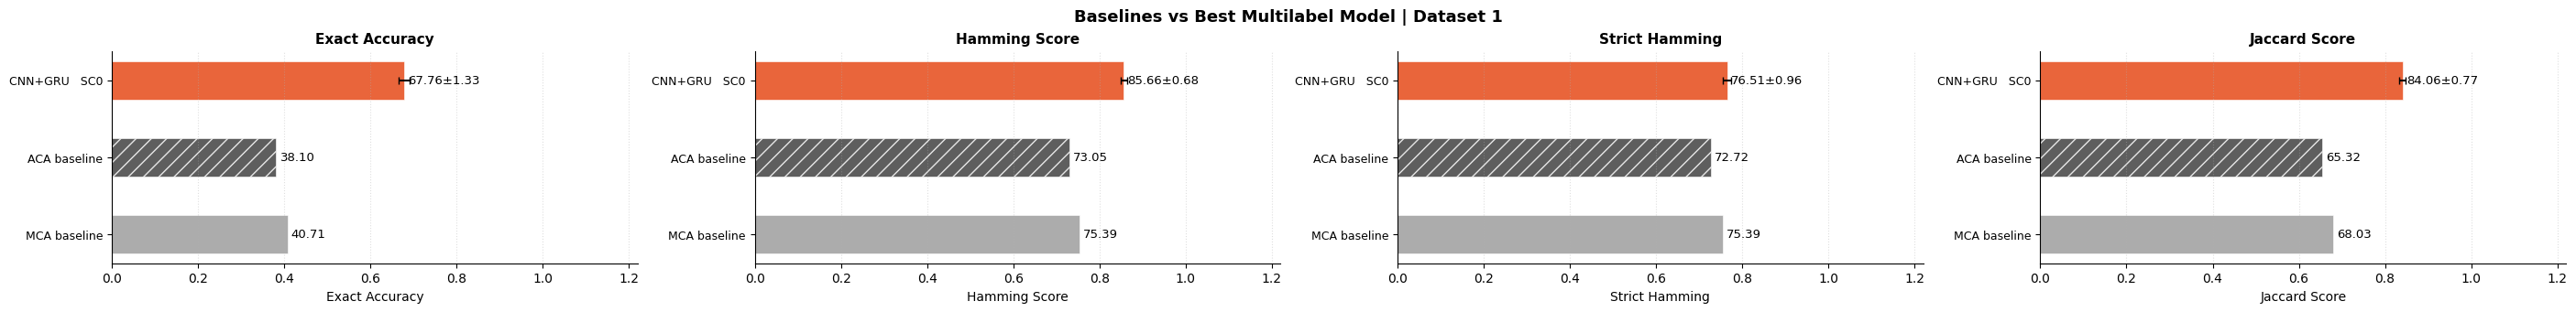

In [32]:
import json

with open(DATA_ROOT_ML / DS1_NAME / 'baseline_performance.json') as f:
    bl_data = json.load(f)

def _label_to_bin(s):
    vec = np.zeros(3, dtype=int)
    for p in s.split('+'): vec[{'KPC':0,'NDM':1,'VIM':2}[p]] = 1
    return vec

def _build_bl_arrays(data, bl_type):
    yt, yp = [], []
    for e in data:
        if e['type'] != bl_type or e['count'] == 0: continue
        yt.extend([_label_to_bin(e['real'])]             * e['count'])
        yp.extend([_label_to_bin(e['predicted_class'])]  * e['count'])
    return np.array(yt), np.array(yp)

yt_mca, yp_mca = _build_bl_arrays(bl_data, 'MCA')
yt_aca, yp_aca = _build_bl_arrays(bl_data, 'ACA')

metrics_mca = {name: (fn(yt_mca, yp_mca), 0.0) for name, _, fn in METRICS}
metrics_aca = {name: (fn(yt_aca, yp_aca), 0.0) for name, _, fn in METRICS}

# Best multilabel model by exact accuracy
all_res  = {**results_a, **{k:{'metrics':v['metrics']} for k,v in results_c.items()}}
best_key = max(all_res, key=lambda k: all_res[k]['metrics']['exact'][0])
best_key ='CNN+GRU   SC0'
best_met = all_res[best_key]['metrics']
print(f'Best model: {best_key.strip()!r}')
for name, label, _ in METRICS:
    m, s = best_met[name]; print(f'  {label}: {m:.4f} ± {s:.4f}')

compare_rows = [
    ('MCA baseline',                 metrics_mca, '#9E9E9E', ''),
    ('ACA baseline',                 metrics_aca, '#424242', '//'),
    (f'{best_key.strip()}',best_met,    '#E64A19', ''),
]
plot_baseline_comparison(compare_rows,
    'Baselines vs Best Multilabel Model | Dataset 1')


In [15]:
list(all_res.keys())

['CNN       SC0',
 'CNN       SC1',
 'GRU       SC0',
 'GRU       SC1',
 'Trans     SC0',
 'Trans     SC1',
 'CNN+GRU   SC0',
 'CNN+GRU   SC1',
 'CNN+GRU   SC2',
 'CNN+GRU   SC3',
 'CNN+Trans SC0',
 'CNN+Trans SC1',
 'CNN+Trans SC2',
 'CNN+Trans SC3',
 'Base    SC0',
 'Base    SC1',
 'Base    SC2',
 'Base    SC3',
 'CRF-MRF SC0',
 'CRF-MRF SC1',
 'CRF-MRF SC2',
 'CRF-MRF SC3',
 'CRF-Chain SC0',
 'CRF-Chain SC1',
 'CRF-Chain SC2',
 'CRF-Chain SC3',
 'CAttn   SC0',
 'CAttn   SC1',
 'CAttn   SC2',
 'CAttn   SC3',
 'CAttn-v2 SC0',
 'CAttn-v2 SC1']

/tmp/ipykernel_3824794/1419621487.py:104: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_3824794/1419621487.py:104: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_3824794/1419621487.py:104: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)


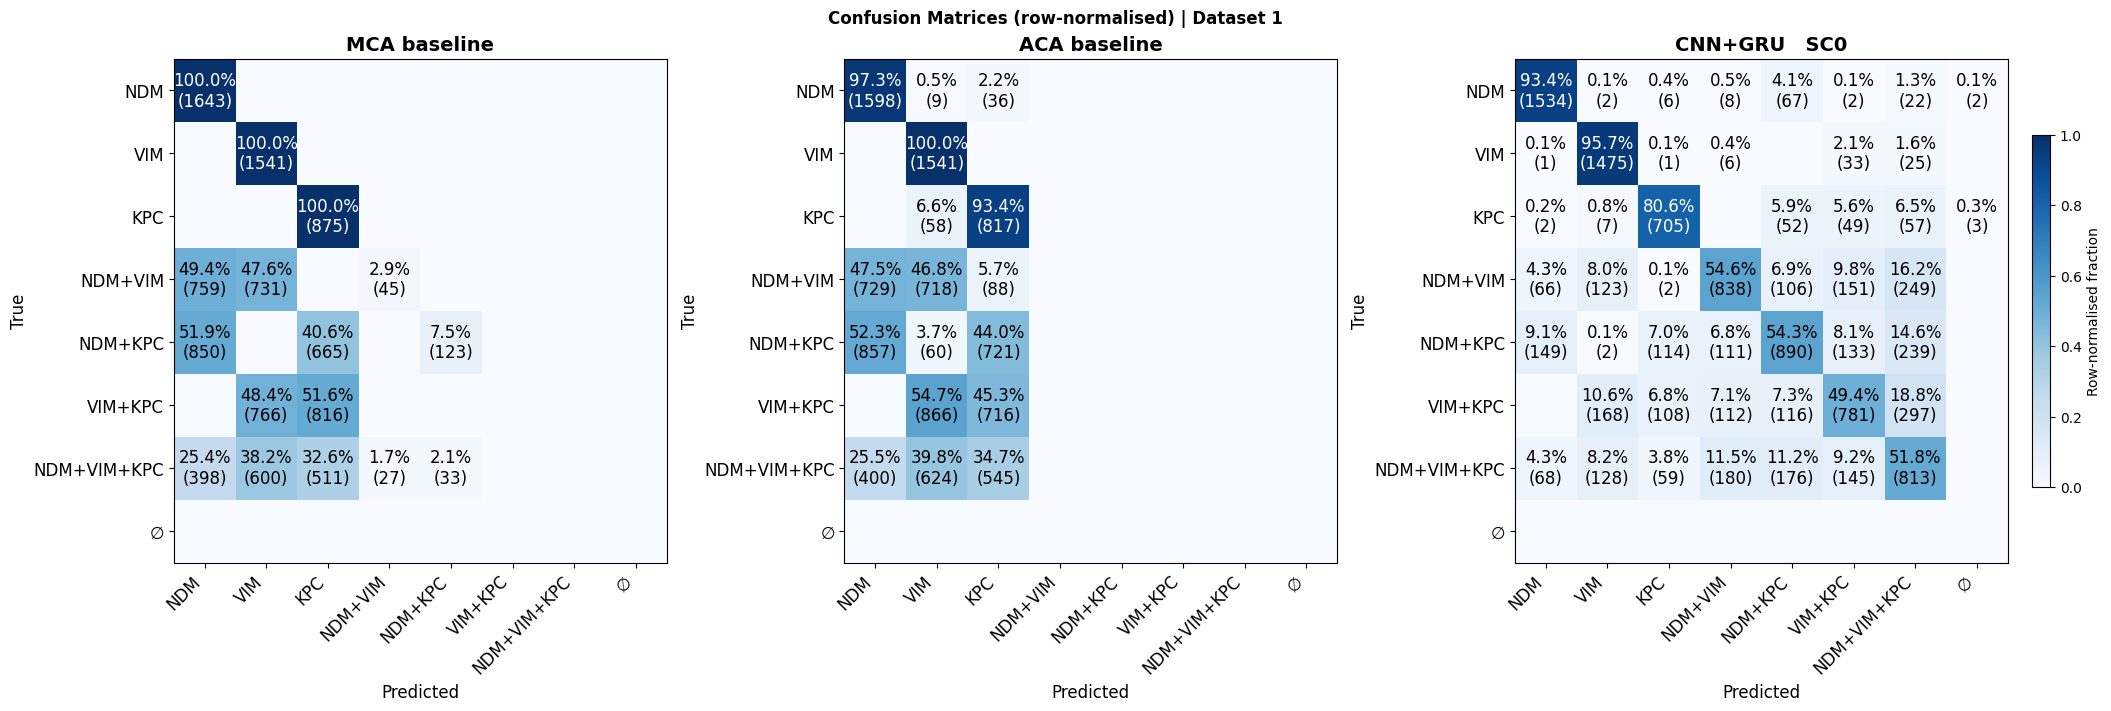

In [28]:
cm_mca = build_cm(yt_mca, yp_mca)
cm_aca = build_cm(yt_aca, yp_aca)

# Pool fold predictions for best model (each sample appears once across folds)
all_defs = ([(lbl, dct, f'y_preds_{sfx}') for lbl, _, dct, sfx in DS1_ALL_FAMILIES] +
            [(lbl, dct, f'y_preds_{sfx}') for lbl, _, dct, sfx in DS1_GRU_DEEP])
best_preds_bin = None
for lbl, dct, pk in all_defs:
    if lbl.strip() == best_key.strip() and pk in dct:
        best_preds_bin = [np.array(yp) for yp in dct[pk]]
        break

yt_best = np.concatenate([np.array(yt) for yt in y_trues_d1])
yp_best = np.concatenate(best_preds_bin)
cm_best = build_cm(yt_best, yp_best)

plot_confusion_matrices(
    [('MCA baseline', cm_mca),
     ('ACA baseline', cm_aca),
     (f'{best_key.strip()}', cm_best)],
    'Confusion Matrices (row-normalised) | Dataset 1'
)


## Section A — All ML Families (Dataset 1 only)

Multilabel performance across CNN / GRU / Transformer / CNN+GRU / CNN+Trans.

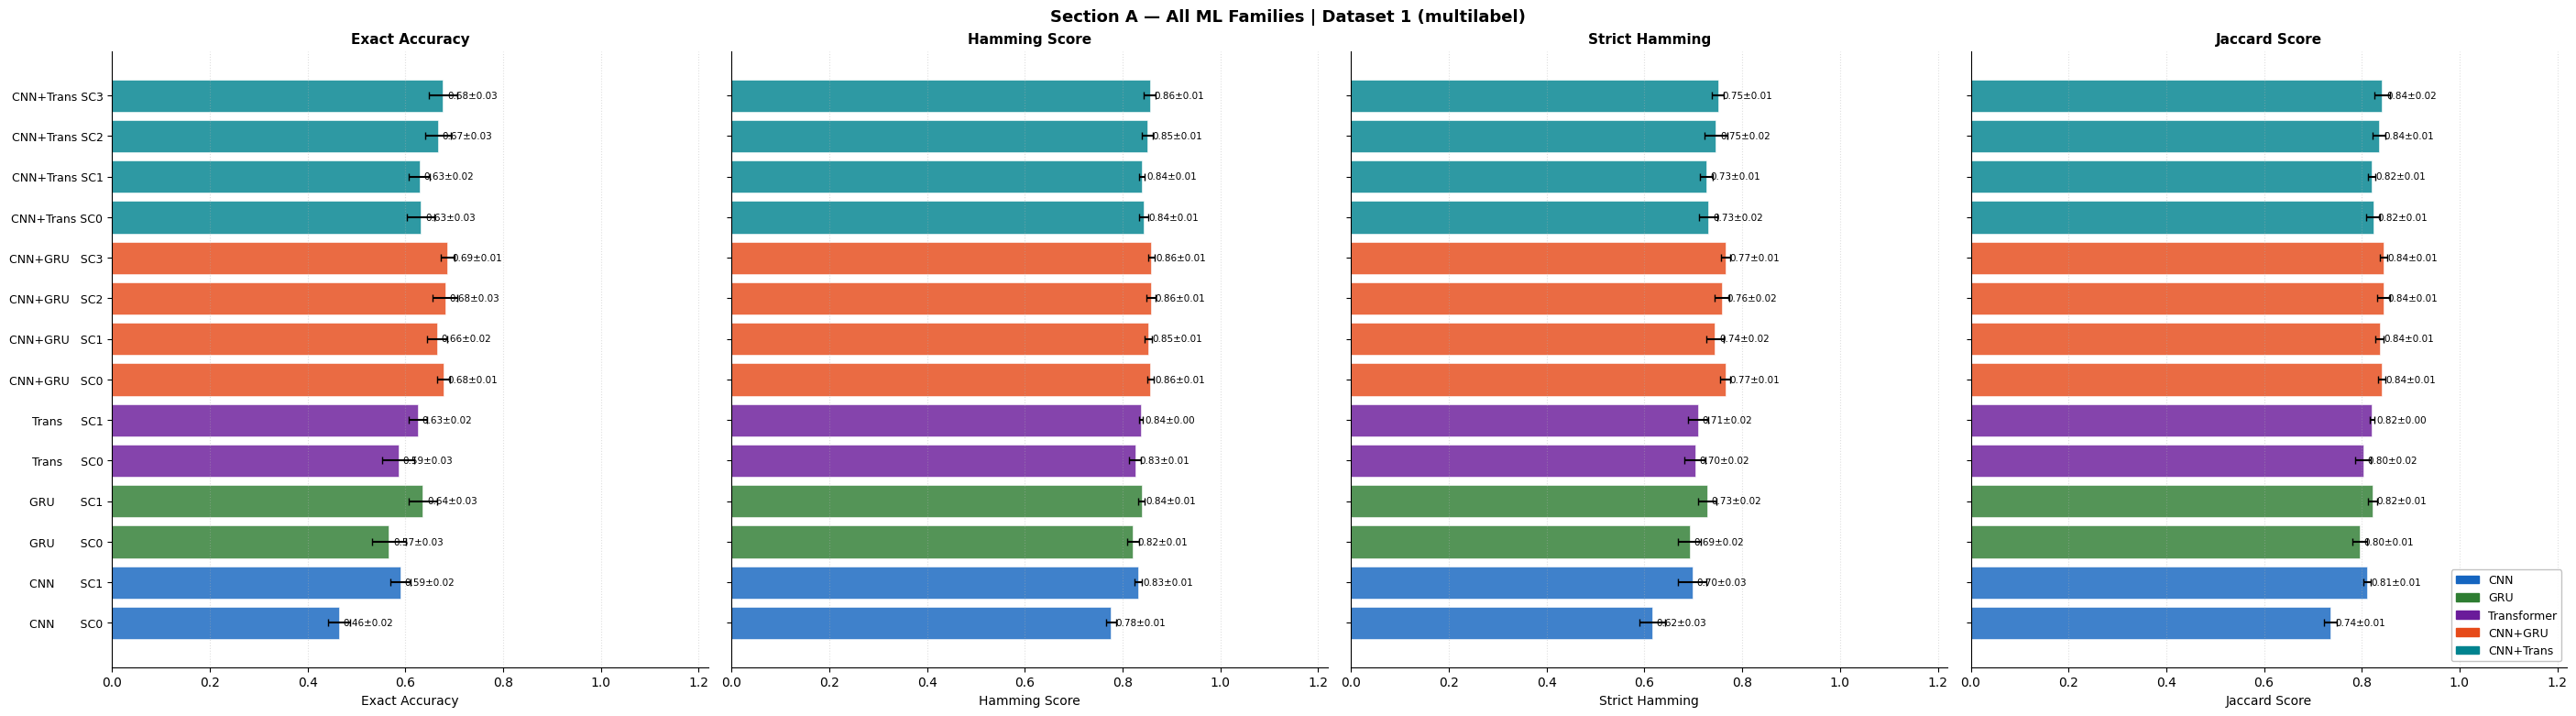

In [8]:
fam_patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
plot_metric_bars(
    results_a,
    'Section A — All ML Families | Dataset 1 (multilabel)',
    color_fn=lambda l: FAMILY_COLORS[results_a[l]['family']],
    legend_handles=fam_patches,
)


## Section B — Cross-Dataset CNN+GRU (SC0–SC3)

DS1 multilabel vs DS2 multiclass; Hamming/Jaccard use binary representation for both.

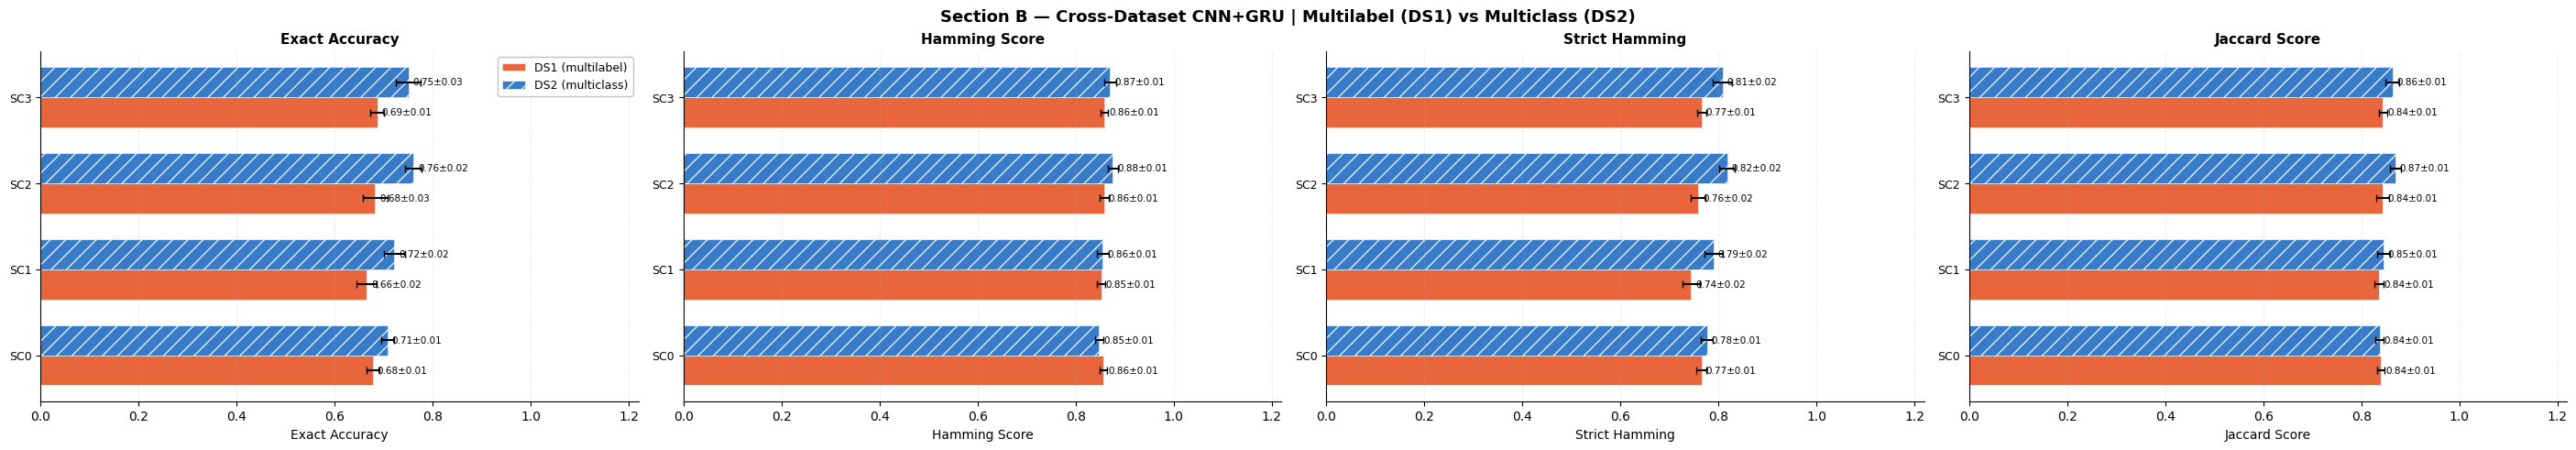

In [9]:
plot_cross_dataset_bars(
    results_d1_gru, results_d2_gru,
    'Section B — Cross-Dataset CNN+GRU | Multilabel (DS1) vs Multiclass (DS2)',
)


## Section C — Dataset 1 CNN+GRU Deep Dive

All variants: Base, CRF-MRF, CRF-Chain, CAttn, CAttn-v2.

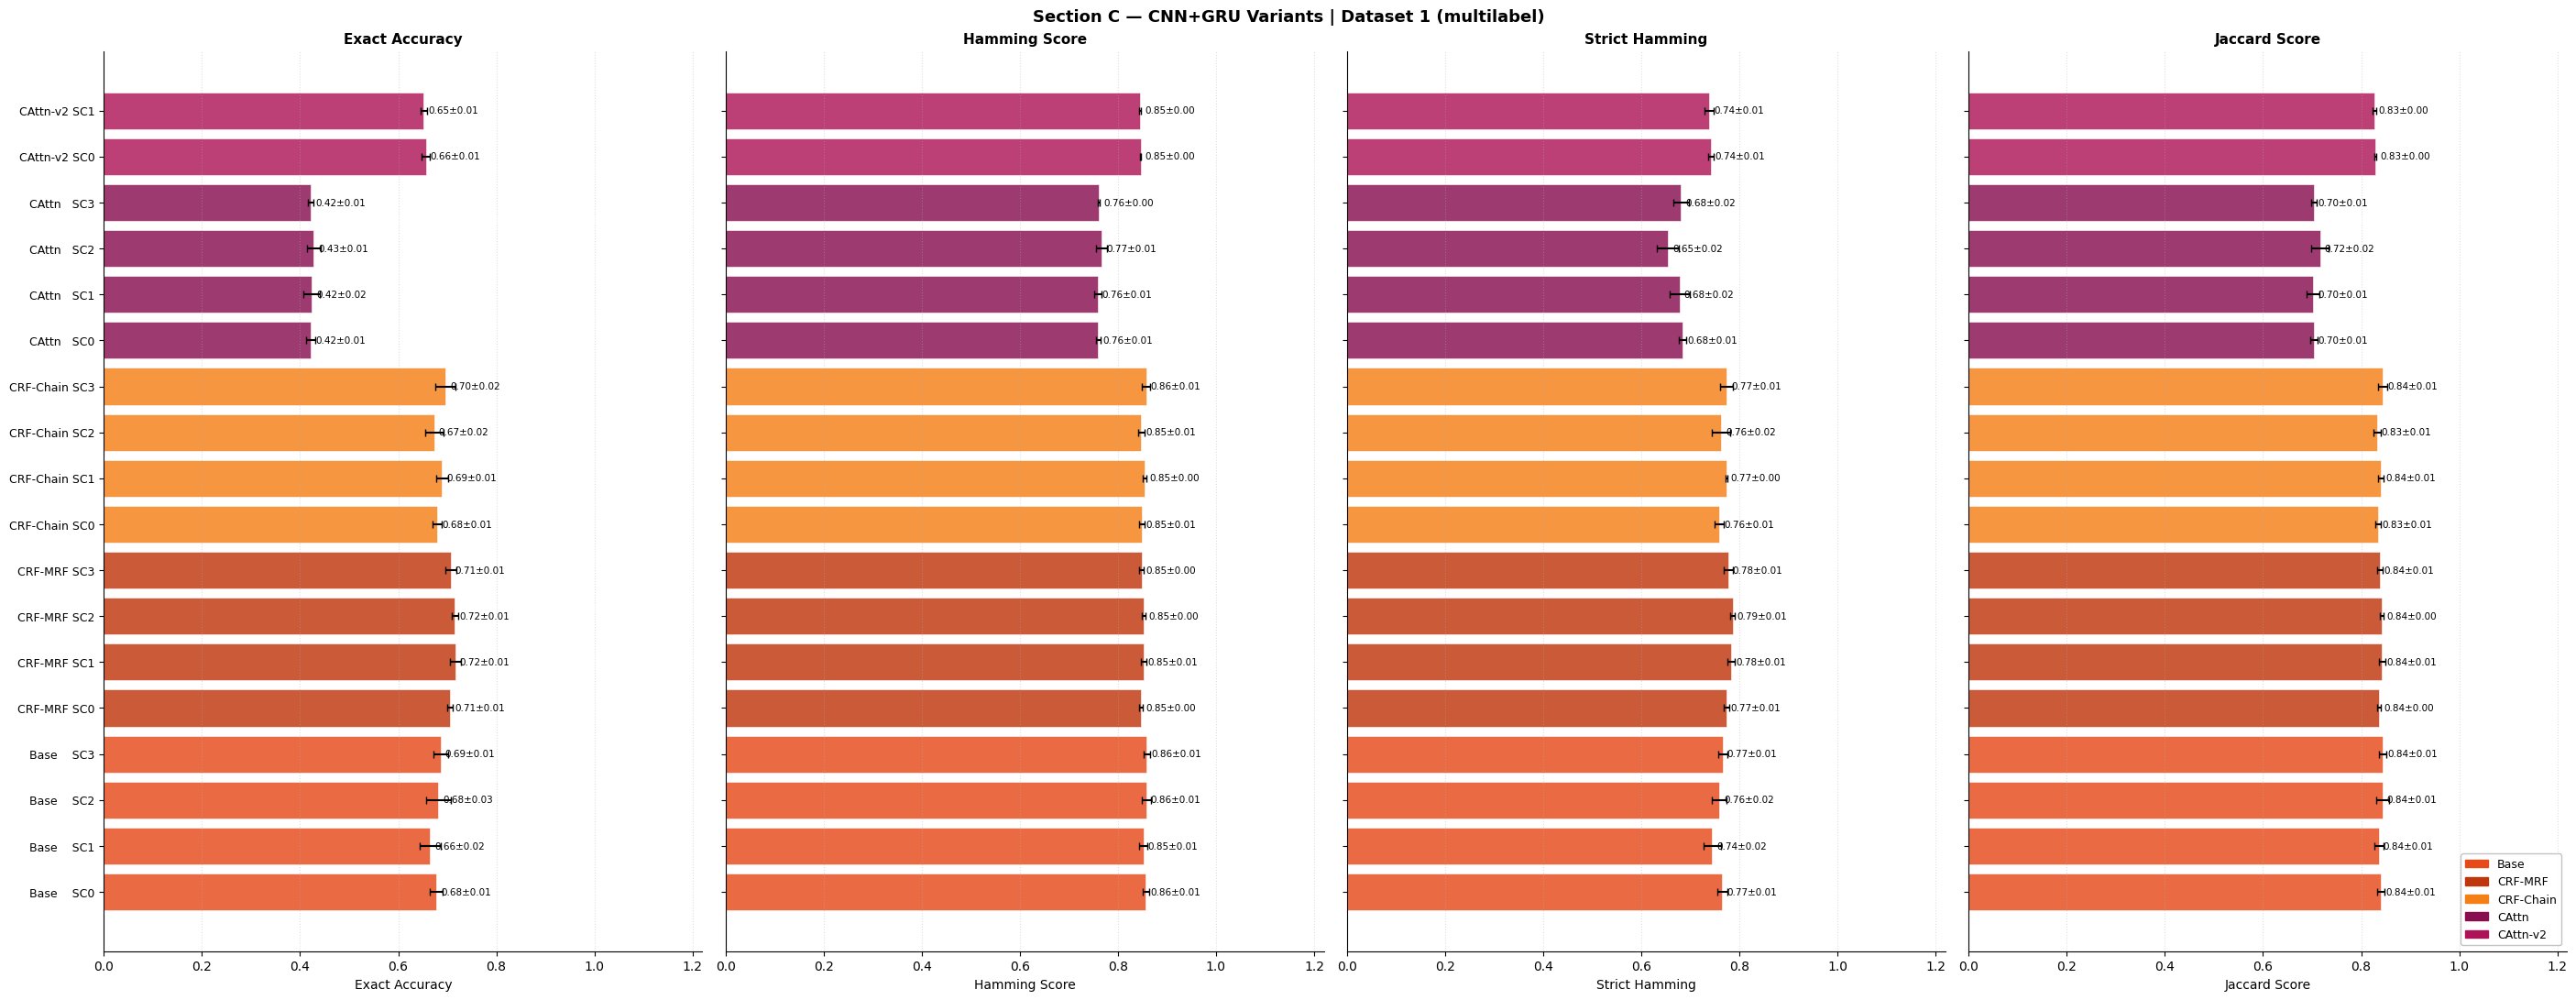

In [10]:
grp_patches = [mpatches.Patch(color=c, label=g) for g, c in GRU_GROUP_COLORS.items()]
plot_metric_bars(
    results_c,
    'Section C — CNN+GRU Variants | Dataset 1 (multilabel)',
    color_fn=lambda l: GRU_GROUP_COLORS[results_c[l]['family']],
    legend_handles=grp_patches,
    row_h=0.6,
)


## Section D — Per-Label & Per-Combination Performance

### D1: Per-label accuracy (Dataset 1, best SC per family)

/tmp/ipykernel_3824794/859524777.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


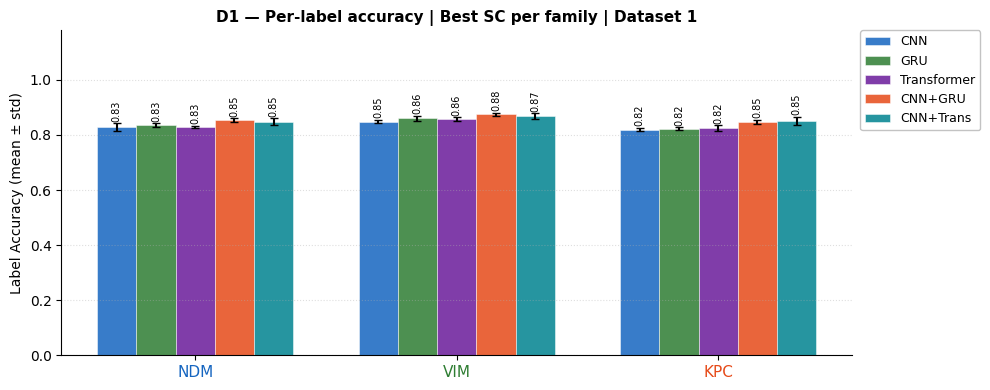

In [11]:
FAMILY_REPR = [
    ('CNN',         d1_main, 'cnn_supcon_'),
    ('GRU',         d1_main, 'gru_supcon_'),
    ('Transformer', d1_main, 'transformer_supcon_'),
    ('CNN+GRU',     d1_main, 'cnn_gru_dual_supcon3_'),
    ('CNN+Trans',   d1_main, 'cnn_trans_dual_supcon3_'),
]
plot_per_label(FAMILY_REPR, y_trues_d1,
    'D1 — Per-label accuracy | Best SC per family | Dataset 1')


### D2: Per-combination exact accuracy — CNN+GRU SC3 (DS1 vs DS2)

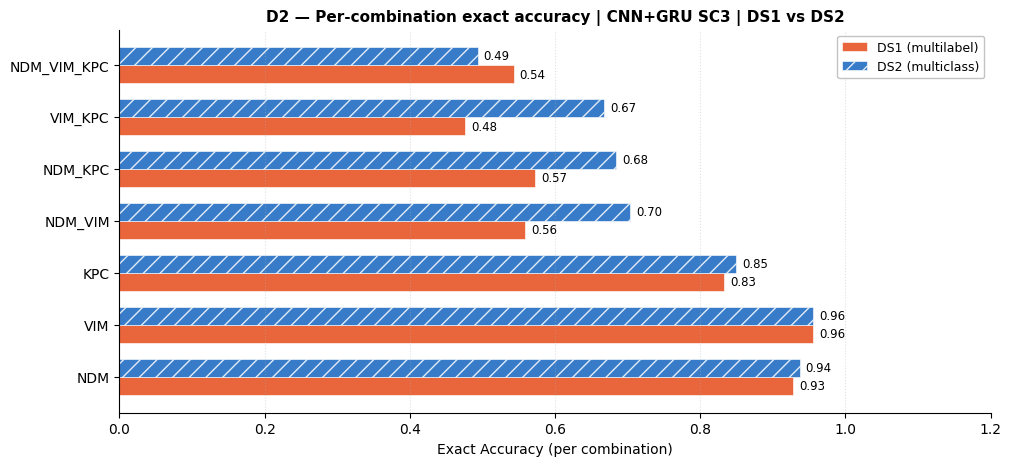

In [12]:
preds_d1_sc3 = [np.array(yp) for yp in d1_main['y_preds_cnn_gru_dual_supcon3_']]
acc_d1 = per_combo_acc(y_trues_d1, preds_d1_sc3)

preds_d2_sc3_bin = [DS2_BIN_MAP[np.array(yp)] for yp in d2['y_preds_AC_cnn_gru_dual_supcon3_']]
acc_d2 = per_combo_acc(y_trues_d2, preds_d2_sc3_bin)

plot_per_combo(
    [('DS1 (multilabel)', acc_d1, DS_COLORS['DS1 (multilabel)'], ''),
     ('DS2 (multiclass)', acc_d2, DS_COLORS['DS2 (multiclass)'], '//')],
    'D2 — Per-combination exact accuracy | CNN+GRU SC3 | DS1 vs DS2',
)


## Section E — Suggested Additional Analyses

**E1 · Confidence Calibration** — Bin `y_probs_*` sigmoid outputs into 10 buckets; plot mean confidence vs observed accuracy per label. Critical for threshold tuning in clinical use.

**E2 · Optimal Threshold Sweep** — Sweep threshold [0.2, 0.8] for DS1 multilabel; plot all 4 metrics vs threshold. Best threshold for Jaccard/Strict Hamming often differs from 0.5.

**E3 · Confusion Flow (Sankey)** — Pool fold predictions; show true→pred transition frequencies to reveal systematic confusions (e.g. NDM_VIM often predicted as NDM alone).

**E4 · Label Cardinality Breakdown** — Split samples by active target count (1, 2, 3). Report all metrics per cardinality. Multi-target samples are typically harder.

**E5 · ROC / PR Curves per Target** — Using `y_probs_*`, plot per-label AUC-ROC and PR curves across families. Captures discrimination ability beyond fixed-threshold metrics.

**E6 · DS2 Full Confusion Matrix** — Standard 7×7 confusion matrix for the multiclass model to identify which combined class confuses with which at the sample level.

## Section F — Grad-CAM & Saliency Analysis

For the selected model, identifies the top-N **correctly predicted** samples per label combination (ranked by prediction confidence), then visualises:

| Column | Description |
|---|---|
| **Raw curve** | Original amplification curve |
| **Grad-CAM** | Class Activation Map — which time-steps most activate the last Conv1D |
| **Saliency** | Absolute input gradient — sensitivity of the output to each cycle |

For multilabel mode each active target gets its own CAM+Saliency pair (e.g. NDM_KPC → 5 columns).

**Requirements** — import the custom model classes *before* calling `plot_gradcam_saliency`:
```python
import sys
# DS1 multilabel models:
sys.path.insert(0, str(_MULTIPLEX_UTILS))
import model_utils_multilabel
# DS2 multiclass models (DDM paper):
sys.path.insert(0, str(_DDM_UTILS))
import model_utils_supcon   # or whichever module the model class lives in
```

In [29]:
import sys
import tensorflow as tf
from scipy.ndimage import gaussian_filter1d

# paths so callers can import custom Keras-serialisable model classes
_MULTIPLEX_UTILS = Path('/vol/bitbucket/gk225/POC_DDM/gk_code/main/multiplex/utils/model_training')
_DDM_UTILS       = Path('/vol/bitbucket/gk225/POC_DDM/gk_code/main/utils/model_training')

# DS2 multiclass label order (sorted alphabetically, LABEL_REMAP applied)
_DS2_CLS_ORDER = ['KPC','NDM','NDM_KPC','VIM','VIM_KPC','NDM_VIM','NDM_VIM_KPC']


# ── label colour helper (same blend rule as dataset profile notebook) ─────────
def _label_color(label):
    parts = label.split('_')
    if len(parts) == 1:
        return BASE_COLORS.get(label, '#888888')
    rgbs = [matplotlib.colors.to_rgb(BASE_COLORS.get(p, '#888888')) for p in parts]
    return tuple(sum(c[i] for c in rgbs) / len(rgbs) for i in range(3))


# ── gradient helpers ──────────────────────────────────────────────────────────
def _find_conv_layer(model):
    """Name of the last Conv1D layer (default Grad-CAM target)."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv1D):
            return layer.name
    raise ValueError('No Conv1D layer found — set cam_layer manually.')

def _find_cls_out_idx(model):
    """Index of the classification head in model.outputs (matches 'cls_out' by name)."""
    for i, out in enumerate(model.outputs):
        if 'cls' in out.name.lower():
            return i
    return 0

def _build_cam_model(model, cam_layer_name, cls_out_idx):
    """Sub-model that returns (conv_activations, cls_output) in one forward pass."""
    return tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(cam_layer_name).output, model.outputs[cls_out_idx]],
    )

def _gradcam_1d(cam_model, x_in, target_idx, n_pts):
    """Grad-CAM for 1-D signal; resampled to n_pts if conv output is shorter."""
    with tf.GradientTape() as tape:
        conv_acts, cls_out = cam_model(x_in, training=False)
        score = cls_out[0, target_idx]
    grads   = tape.gradient(score, conv_acts)[0]           # (T_cam, C)
    weights = tf.reduce_mean(grads, axis=0)                # (C,)
    cam = tf.reduce_sum(tf.nn.relu(conv_acts[0] * weights), axis=-1).numpy()  # (T_cam,)
    lo, hi = cam.min(), cam.max()
    cam = (cam - lo) / (hi - lo + 1e-8)
    if len(cam) != n_pts:                                  # upsample to input length
        cam = np.interp(np.linspace(0,1,n_pts), np.linspace(0,1,len(cam)), cam)
    return cam

def _saliency_1d(model, cls_out_idx, x_np, target_idx):
    """Absolute input gradient (saliency), normalised to [0, 1]."""
    x_var = tf.Variable(x_np[np.newaxis], dtype=tf.float32)
    with tf.GradientTape() as tape:
        out = model(x_var, training=False)
        cls_out = out[cls_out_idx] if isinstance(out, (list, tuple)) else out
        score   = cls_out[0, target_idx]
    grads = tape.gradient(score, x_var).numpy().reshape(-1)
    sal   = np.abs(grads)
    lo, hi = sal.min(), sal.max()
    return (sal - lo) / (hi - lo + 1e-8)


# ── main function ─────────────────────────────────────────────────────────────
def plot_gradcam_saliency(
    model_path,
    mode='multilabel',
    n_top=3,
    cam_layer=None,
    smooth_sigma=1.0,
):
    """
    Grad-CAM and saliency maps for the top-N highest-confidence correctly
    predicted samples per label combination.

    Parameters
    ----------
    model_path : str | Path
        Saved Keras model (.keras / .h5). Import the model's custom classes
        before calling (see Section F markdown for instructions).
    mode : 'multilabel' | 'multiclass'
        'multilabel' uses DS1 (sigmoid, 3 binary outputs);
        'multiclass' uses DS2 (softmax, 7 classes).
    n_top : int
        Samples to visualise per label (highest confidence first).
    cam_layer : str | None
        Conv1D layer name for Grad-CAM; last Conv1D auto-detected if None.
    smooth_sigma : float
        Gaussian sigma for CAM/saliency smoothing (0 = off).
    """
    model = tf.keras.models.load_model(str(model_path), compile=False)
    print(f'Loaded: {Path(model_path).name}')

    if cam_layer is None:
        cam_layer = _find_conv_layer(model)
        print(f'Grad-CAM layer (auto): {cam_layer!r}')
    cls_out_idx = _find_cls_out_idx(model)
    n_cls = int(model.outputs[cls_out_idx].shape[-1])
    print(f'cls head idx={cls_out_idx}  n_cls={n_cls}  outputs={[o.name for o in model.outputs]}')

    cam_model = _build_cam_model(model, cam_layer, cls_out_idx)

    # ── load curves ───────────────────────────────────────────────────────────
    curve_path = (DATA_ROOT_ML  / DS1_NAME / 'curve_for_training_ml.joblib') if mode == 'multilabel' \
            else (DATA_ROOT_DDM / DS2_NAME / 'curve_for_training.joblib')
    d_curves   = joblib.load(curve_path)
    raw_labels = np.array([LABEL_REMAP.get(l, l) for l in d_curves['well_labels']])
    curves_all = d_curves['curves']['ori_curves']          # (N, T)
    ts         = np.asarray(d_curves['timestamps'])
    T          = curves_all.shape[1]
    x_all      = curves_all[:, :, np.newaxis].astype(np.float32)  # (N, T, 1)

    # ── batch inference: get probs for all samples ────────────────────────────
    print(f'Running inference on {len(x_all):,} samples...')
    BATCH, probs_parts = 512, []
    for s in range(0, len(x_all), BATCH):
        out = model(x_all[s:s+BATCH], training=False)
        cls_out = out[cls_out_idx] if isinstance(out, (list, tuple)) else out
        probs_parts.append(cls_out.numpy())
    probs_all = np.concatenate(probs_parts)                # (N, n_cls)

    if mode == 'multilabel':
        y_pred_bin = (probs_all > 0.5).astype(int)        # (N, 3)
    else:
        y_pred_bin = DS2_BIN_MAP[np.argmax(probs_all, axis=1)]  # (N, 3)

    # ── per label: top-N correct by confidence ────────────────────────────────
    for combo_label in LABEL_ORDER:
        mask = raw_labels == combo_label
        if not mask.any():
            continue
        idxs = np.where(mask)[0]

        if mode == 'multilabel':
            parts       = combo_label.split('_')
            true_vec    = np.array([1 if t in parts else 0 for t in TARGET_NAMES])
            active_cols = [i for i, t in enumerate(TARGET_NAMES) if t in parts]
            correct     = np.all(y_pred_bin[idxs] == true_vec, axis=1)
            # confidence = min sigmoid over active targets (weakest link)
            conf        = probs_all[idxs][:, active_cols].min(axis=1)
            cam_targets = [(TARGET_NAMES[c], c) for c in active_cols]
        else:
            cls_int     = _DS2_CLS_ORDER.index(combo_label)
            true_bin    = DS2_BIN_MAP[cls_int]
            correct     = np.all(y_pred_bin[idxs] == true_bin, axis=1)
            conf        = probs_all[idxs, cls_int]
            cam_targets = [(combo_label, cls_int)]

        if not correct.any():
            print(f'  [{combo_label}] — no correct predictions, skipping')
            continue

        order    = np.argsort(conf[correct])[::-1]
        top_idxs = idxs[correct][order[:n_top]]
        top_conf = conf[correct][order[:n_top]]
        n_show   = len(top_idxs)
        n_pairs  = len(cam_targets)
        n_cols   = 1 + n_pairs * 2
        combo_color = _label_color(combo_label)

        fig, axes = plt.subplots(
            n_show, n_cols,
            figsize=(4.5 * n_cols, 3.0 * n_show),
            constrained_layout=True,
        )
        if n_show == 1: axes = axes[np.newaxis, :]
        if n_cols  == 1: axes = axes[:, np.newaxis]

        for row, (sidx, sconf) in enumerate(zip(top_idxs, top_conf)):
            x_np = x_all[sidx]                            # (T, 1)
            x_in = tf.constant(x_np[np.newaxis])          # (1, T, 1)

            # col 0 — raw curve
            ax0 = axes[row, 0]
            ax0.plot(ts, x_np[:, 0], color=combo_color, linewidth=1.6)
            ax0.set_ylabel('Signal', fontsize=8)
            ax0.set_xlabel('Cycle',  fontsize=8)
            ax0.spines[['top','right']].set_visible(False)
            ax0.set_title(
                f'Raw curve ({combo_label})' if row == 0
                else f'Sample #{sidx}  conf={sconf:.3f}',
                fontsize=9, fontweight='bold' if row == 0 else 'normal',
            )

            # col pairs — Grad-CAM + Saliency per active target
            for ti, (t_name, t_idx) in enumerate(cam_targets):
                t_color = BASE_COLORS.get(t_name, combo_color)

                cam = _gradcam_1d(cam_model, x_in, t_idx, T)
                sal = _saliency_1d(model, cls_out_idx, x_np, t_idx)
                if smooth_sigma > 0:
                    cam = gaussian_filter1d(cam, smooth_sigma)
                    sal = gaussian_filter1d(sal, smooth_sigma)
                    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

                for col_off, data, col_lbl in [(0, cam, 'Grad-CAM'), (1, sal, 'Saliency')]:
                    ax  = axes[row, 1 + ti*2 + col_off]
                    ax2 = ax.twinx()
                    ax.plot(ts, x_np[:, 0], color='#9E9E9E', linewidth=0.9, alpha=0.5, zorder=1)
                    ax2.fill_between(ts, data, alpha=0.28, color=t_color, zorder=2)
                    ax2.plot(ts, data, color=t_color, linewidth=1.4, zorder=3)
                    ax2.set_ylim(-0.05, 1.15)
                    ax2.set_ylabel(col_lbl, fontsize=7, color=t_color)
                    ax2.tick_params(axis='y', labelsize=6, colors=t_color)
                    ax.set_xlabel('Cycle', fontsize=8)
                    ax.spines[['top']].set_visible(False)
                    ax.tick_params(labelsize=7)
                    if row == 0:
                        ax.set_title(f'{col_lbl}\n[{t_name}]', fontsize=9, fontweight='bold')
                    else:
                        ax.set_title(f'conf={sconf:.3f}', fontsize=8)

        fig.suptitle(
            f'Grad-CAM & Saliency | {combo_label} | {mode} | top-{n_show} confidence',
            fontsize=12, fontweight='bold',
        )
        plt.show()

print('plot_gradcam_saliency ready.')


2026-07-21 19:46:08.776143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 19:46:08.849220: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 19:46:08.849478: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-21 19:46:08.959564: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-21 19:46:15.706263: W tensorflow/com

plot_gradcam_saliency ready.



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



2026-07-21 19:48:00.126721: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1491 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


Loaded: cnn_gru_dual_None_ML SC0.keras
Grad-CAM layer (auto): 'conv1d_1'
cls head idx=0  n_cls=3  outputs=['keras_tensor_26']
Running inference on 10,383 samples...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['curve_input']
Received: inputs=Tensor(shape=(512, 45, 1))
  warnings.warn(msg)
2026-07-21 19:48:01.872442: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['curve_input']
Received: inputs=Tensor(shape=(143, 45, 1))
  warnings.warn(msg)


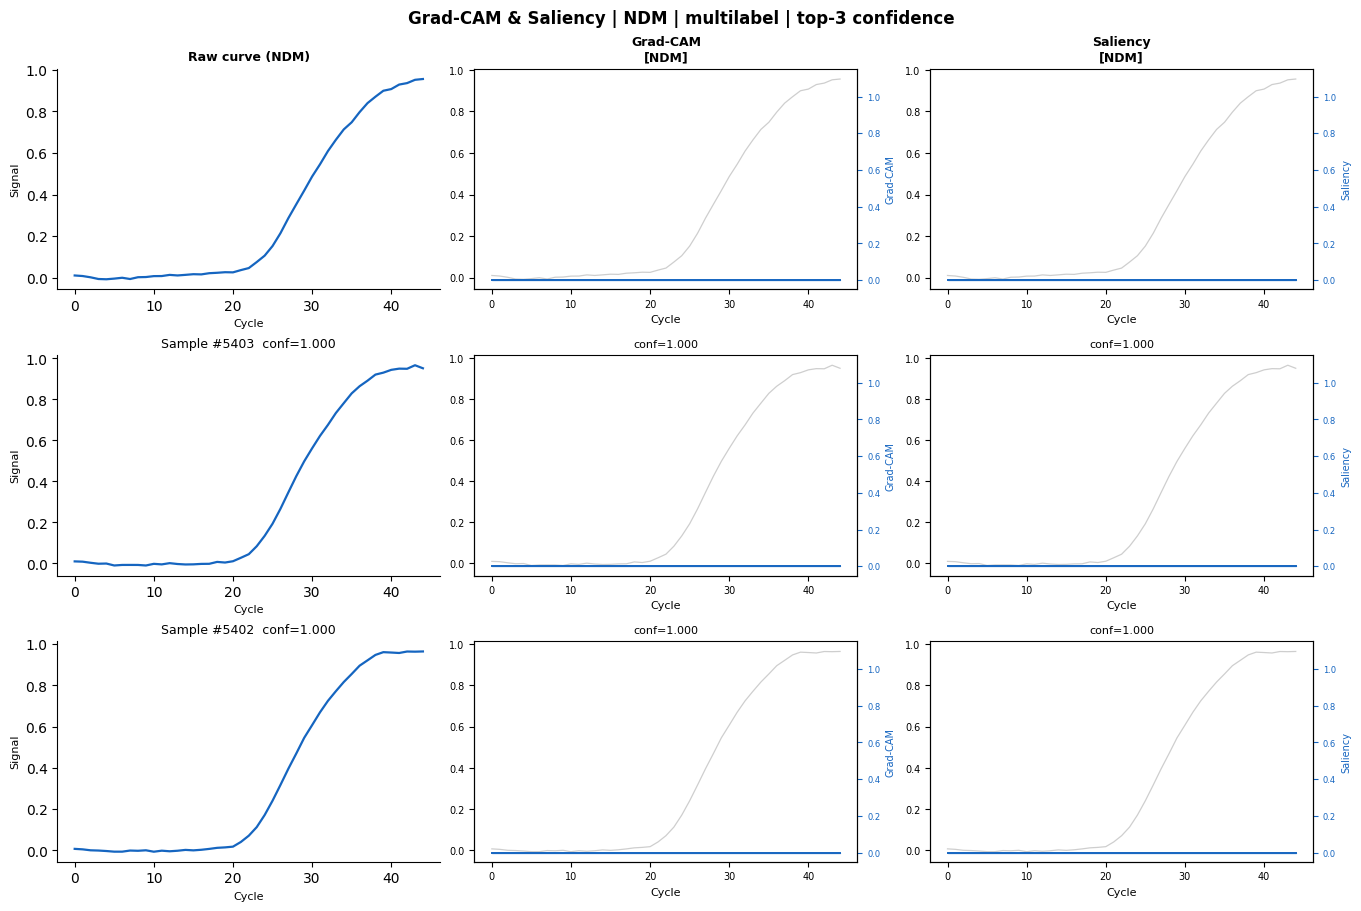

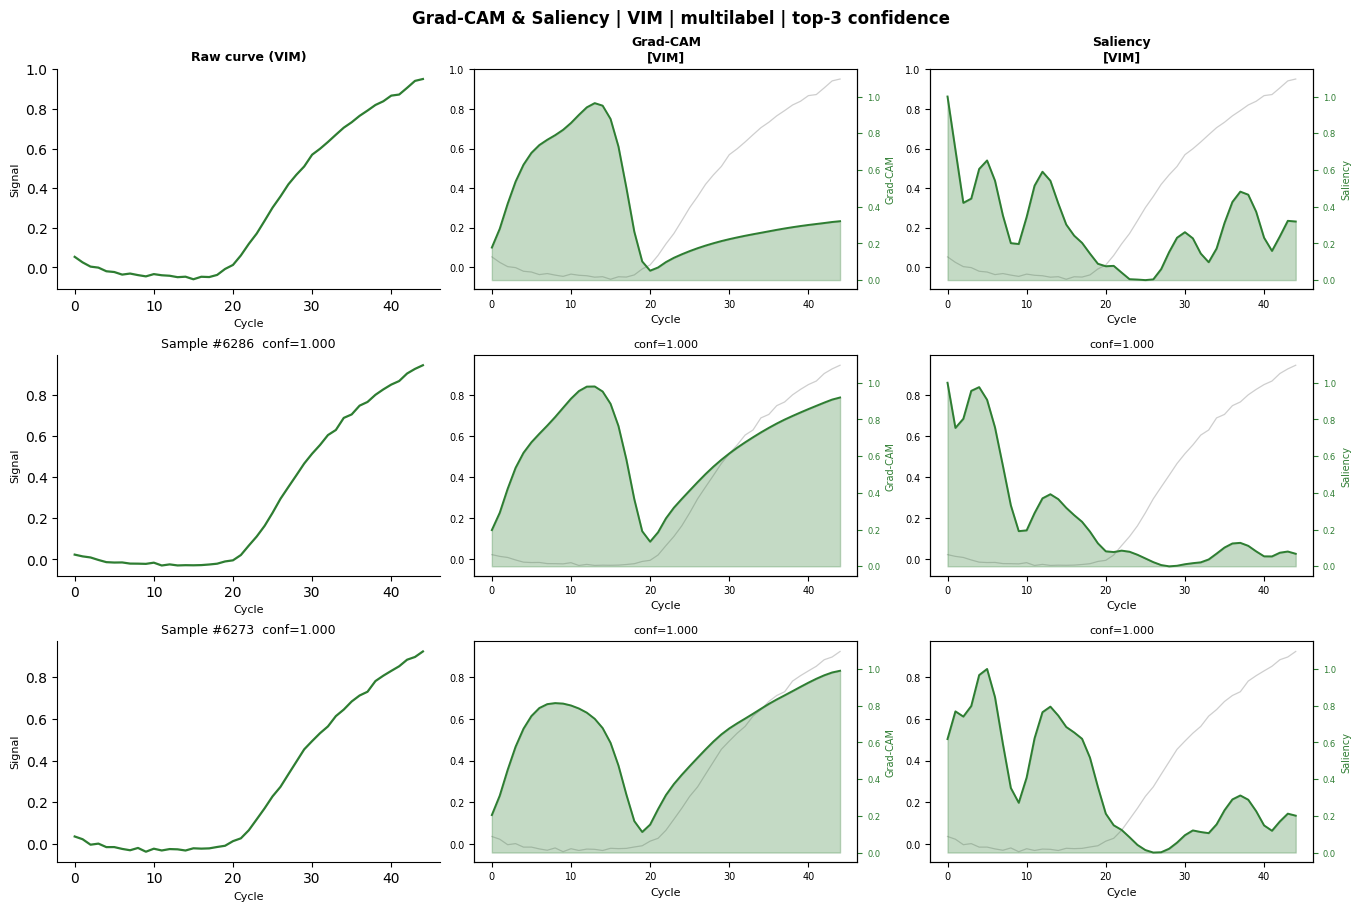

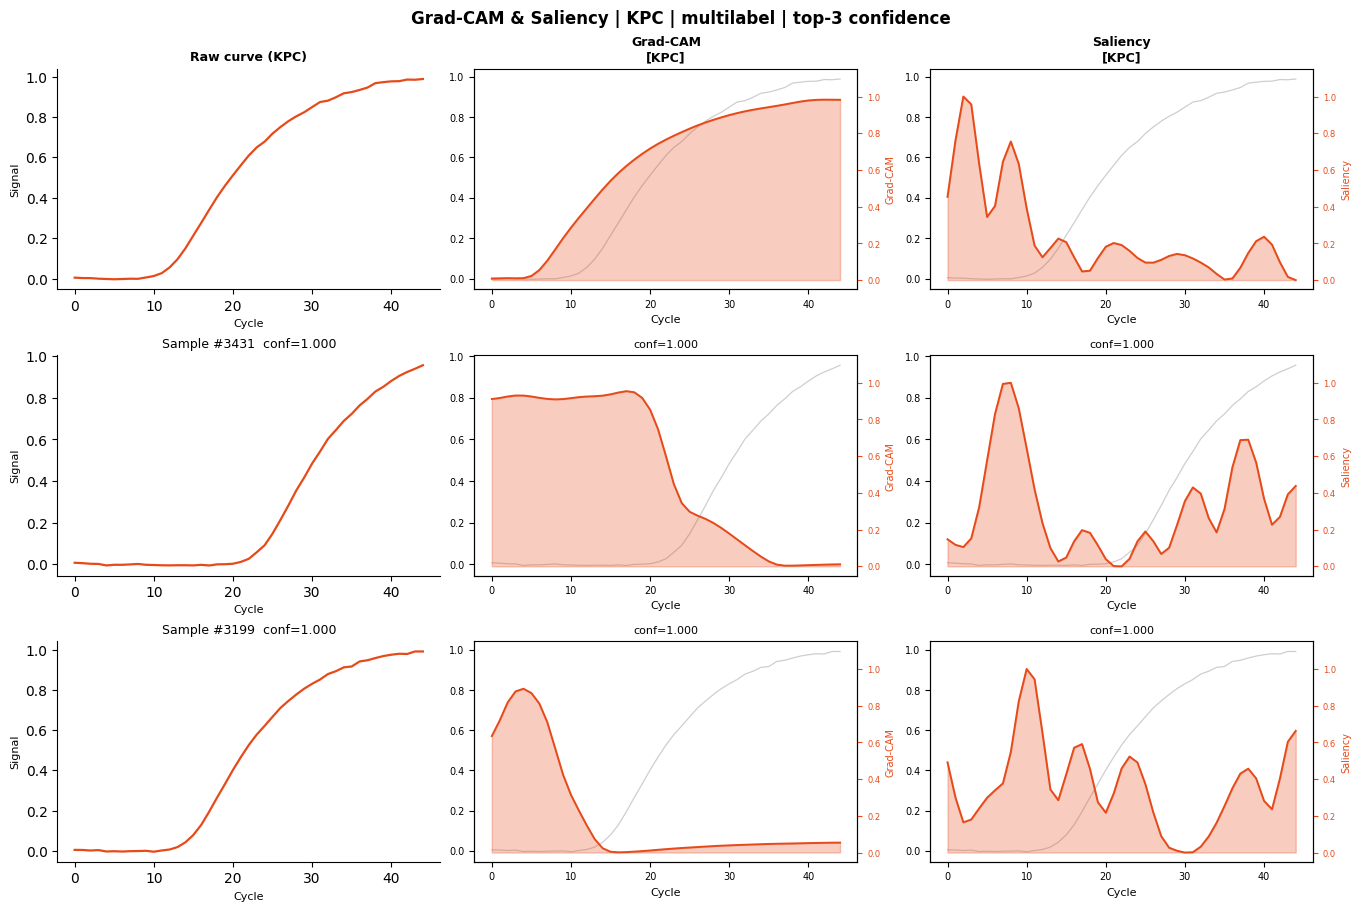

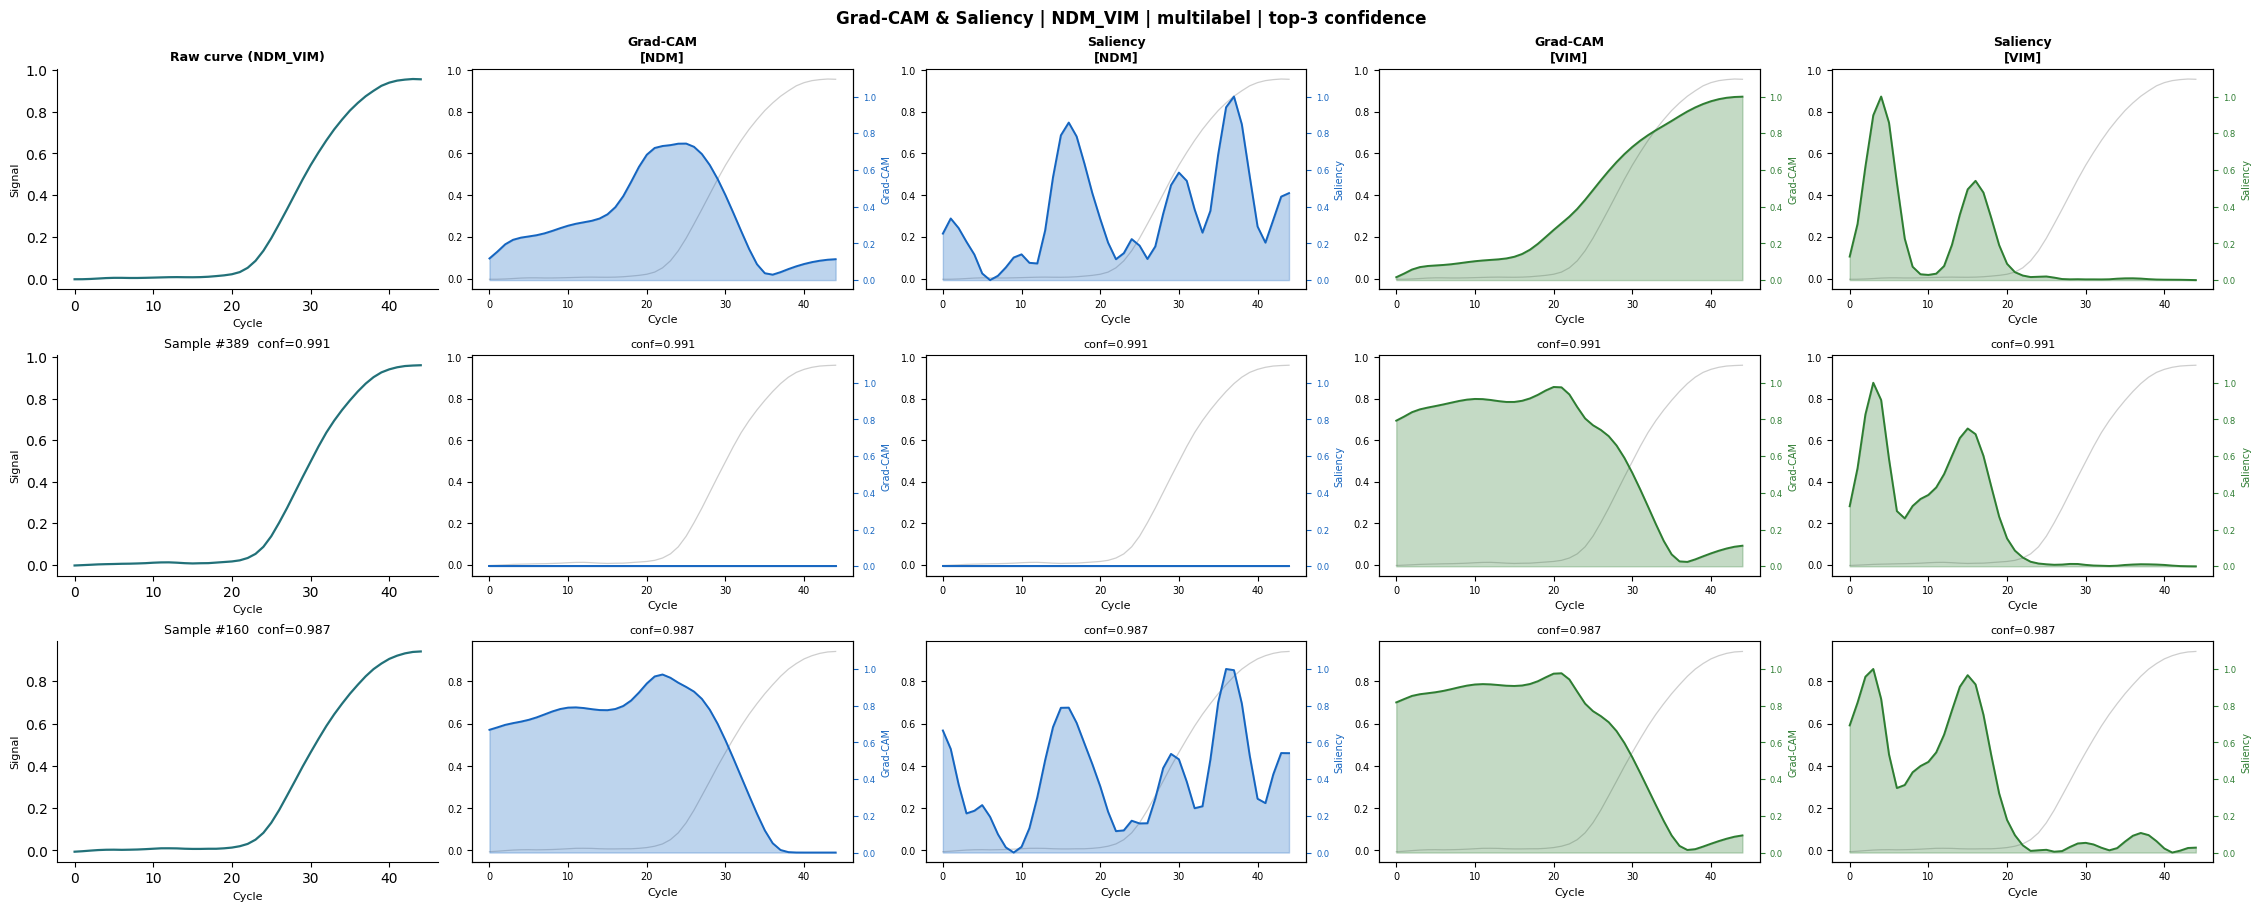

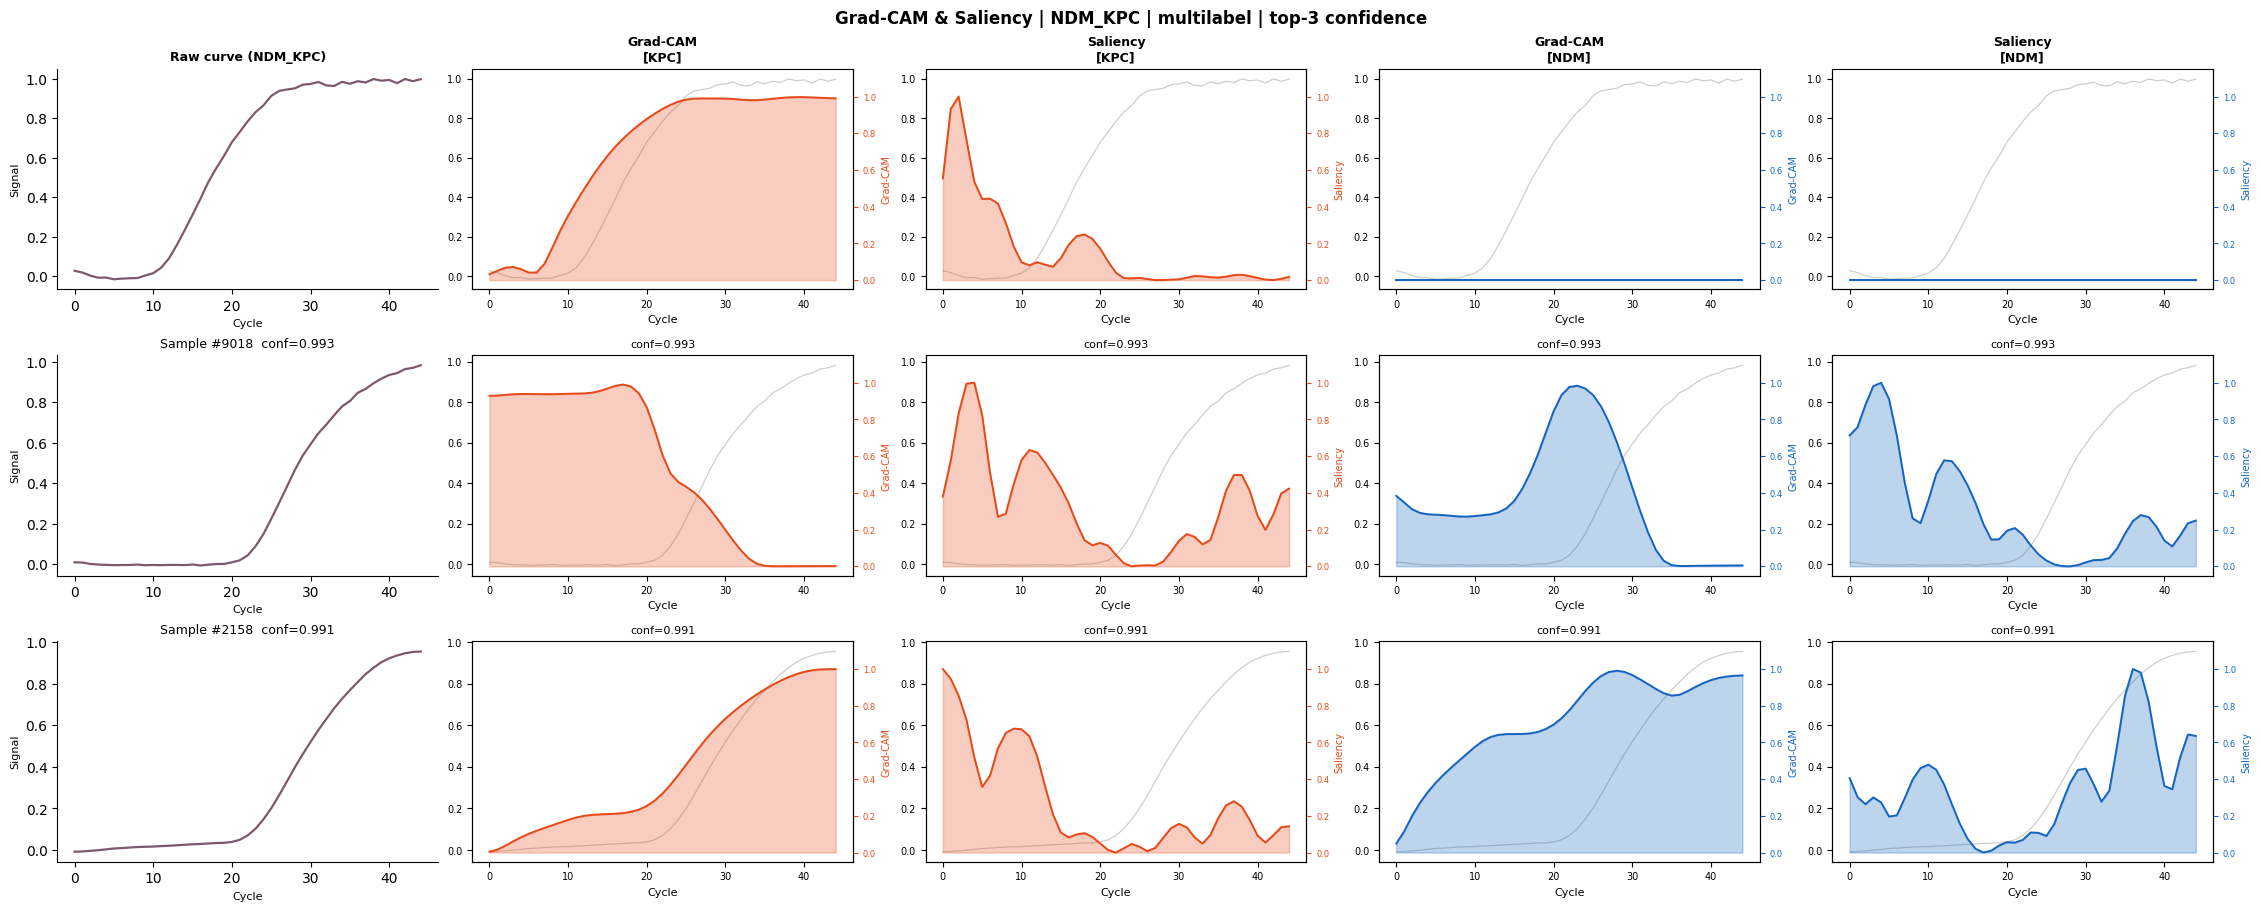

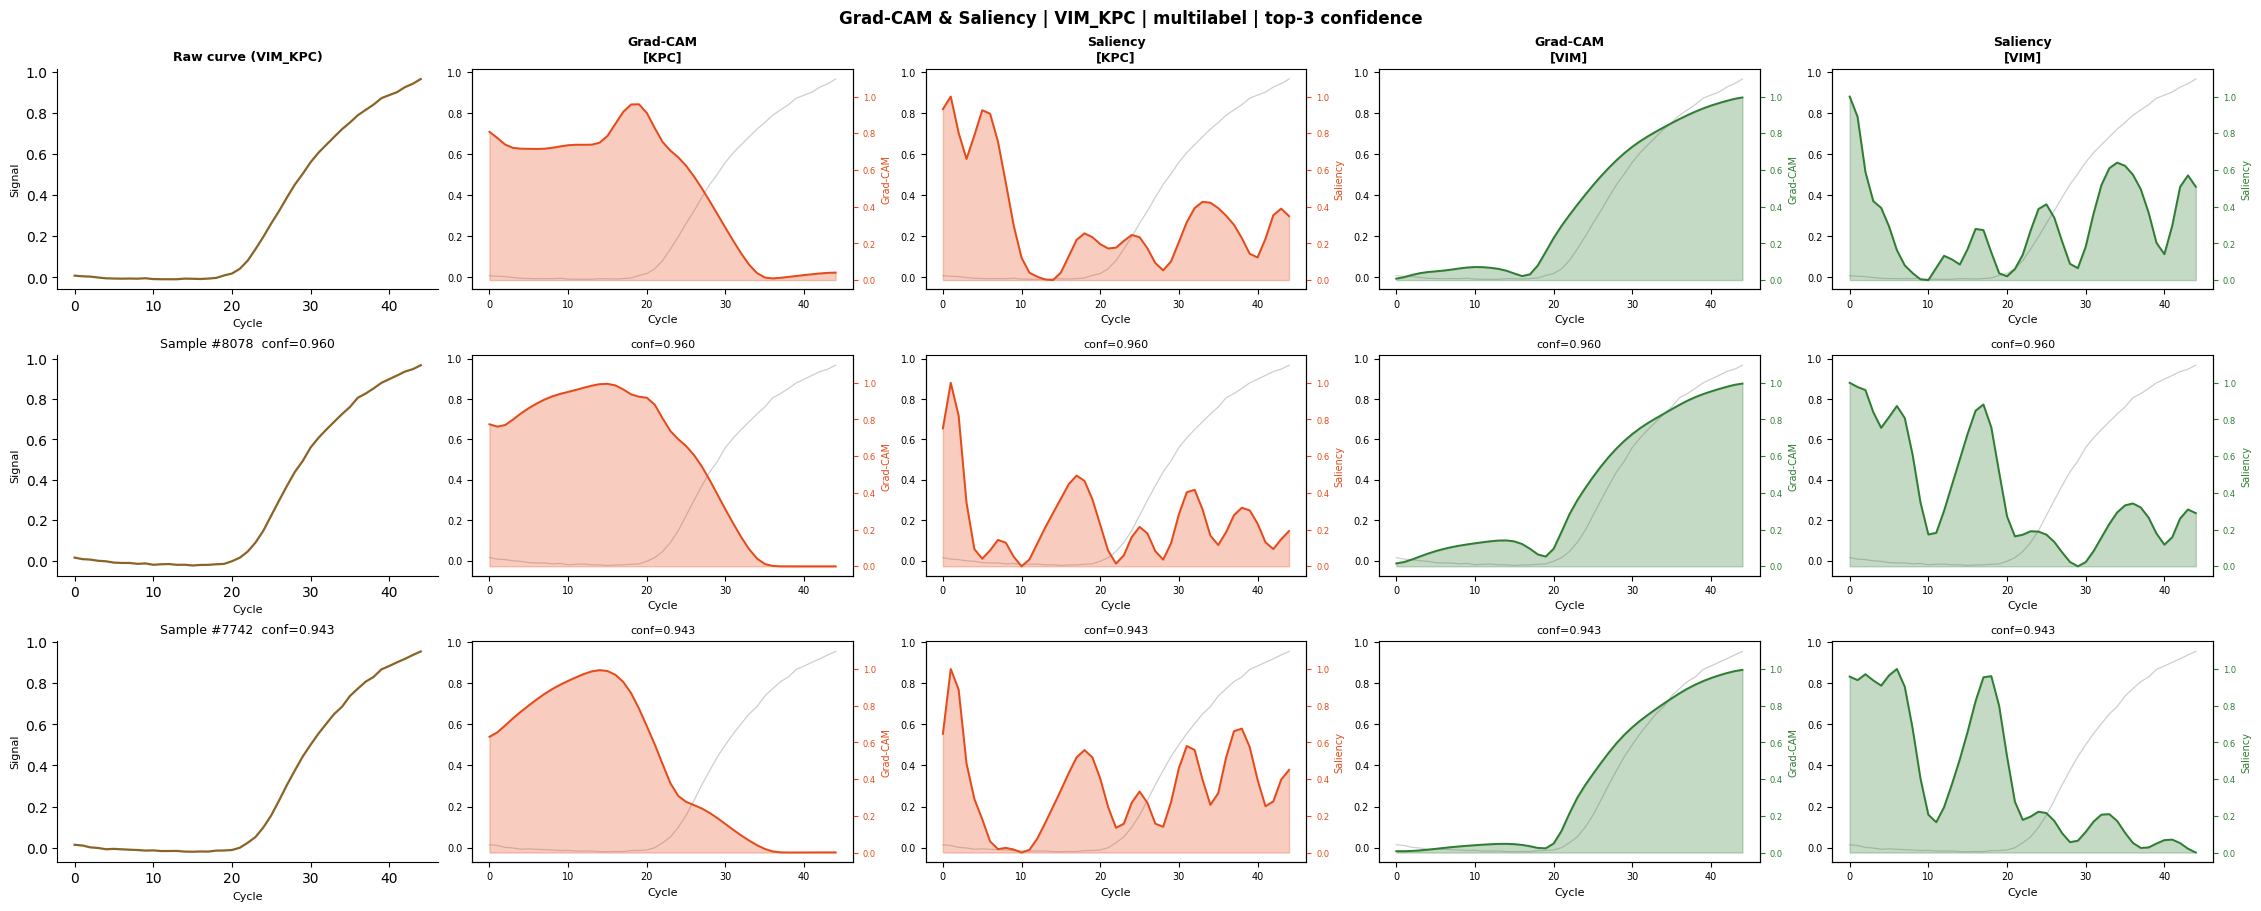

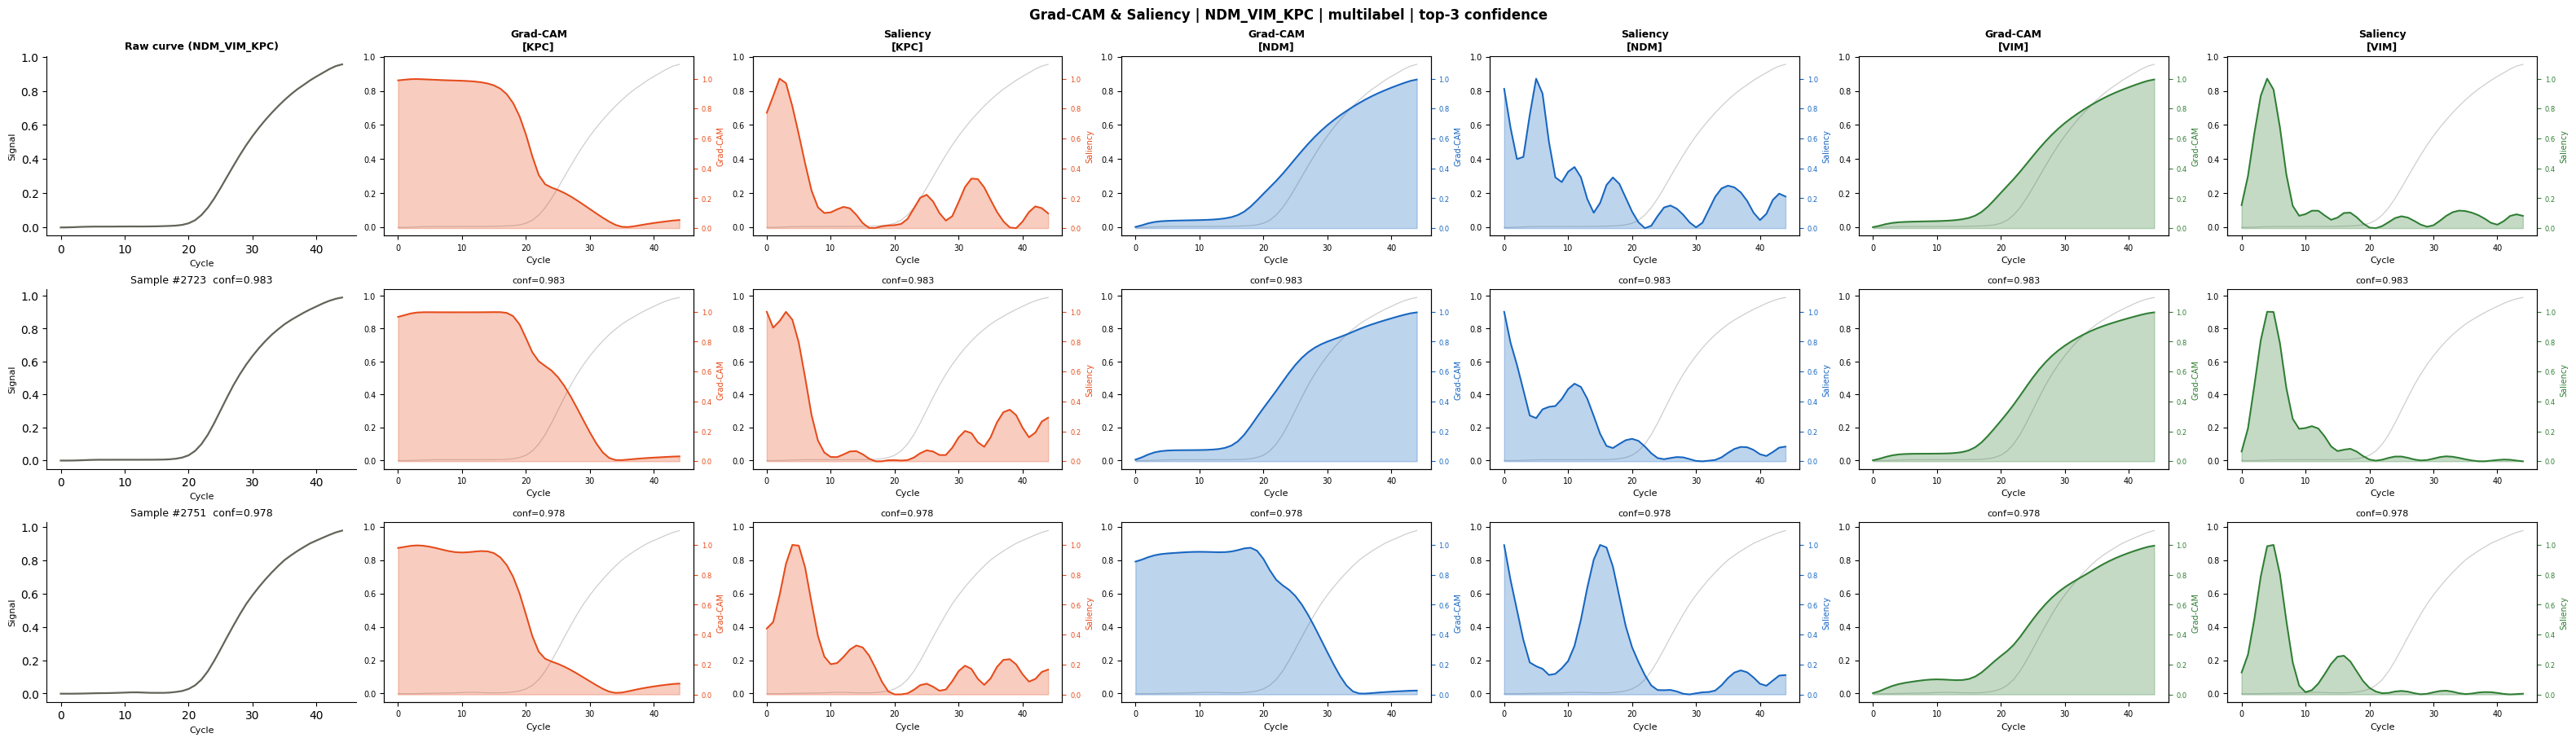

In [30]:
# ── Register custom model classes before load_model ──────────────────────────
sys.path.insert(0, str(_MULTIPLEX_UTILS))
import model_utils_multilabel  # registers MultiLabel*Model classes

# DS1 — multilabel CNN+GRU SC3
MODEL_DS1 = DATA_ROOT_ML / DS1_NAME / 'models' / 'cnn_gru_dual_None_ML SC0.keras'

plot_gradcam_saliency(
    MODEL_DS1,
    mode='multilabel',
    n_top=3,
    smooth_sigma=1.0,
)

# ── DS2 multiclass (uncomment and add appropriate model utils import) ─────────
# sys.path.insert(0, str(_DDM_UTILS))
# import model_utils_supcon
# MODEL_DS2 = DATA_ROOT_DDM / DS2_NAME / 'model_interpretation' / 'cnn_gru_dual_supcon3_None_ori_curve_model.keras'
# plot_gradcam_saliency(MODEL_DS2, mode='multiclass', n_top=3)
